# 260: one table of kmerseek region calls, merged across alphabet-ksize pairs

This notebook builds one table from kmerseek's region calls on the 998 midi-plus human
queries (chromosome 6 plus the MHC's partners on other chromosomes). One row is one query,
one target species, one merged region and one alphabet-ksize pair (one reduced amino-acid
alphabet at one k-mer size; the column is called `arm`).

A region call is a stretch of the human query that kmerseek matched, without gaps, to one
target protein. One stretch that matches 40 zebrafish proteins is 40 calls. Calls on the
same query and species, from any target protein and any alphabet-ksize pair, become one
merged region when they overlap by at least half the shorter call. The joins chain: if A
joins B and B joins C, then A, B and C are one merged region.

Each merged region is compared with two truth sets on the same query: Pfam domains, and
the Swiss-Prot features notebook 231 scored on (DOMAIN, REGION, TRANSMEM, REPEAT, BINDING
and the rest). Landed fraction = overlap / region length. Coverage fraction = overlap /
feature length. A region is a true call when its landed fraction is at least 0.5. There
is no IoU cut.

Only calls with `region_evalue` < 10 enter the table. `region_evalue` is kmerseek's
Karlin-Altschul E-value: how many regions scoring at least this well a search of this
database would find by chance.

## Which search outputs this execution reads

The kmerseek 0.4 midi-plus run with extension (`make run-midi-plus-0.4-extend`, PR #88)
has not run yet. Without extension kmerseek 0.4 writes `region_evalue` as infinity on
every row, so the earlier 0.4 attempt cannot feed this table. This execution reads the
five kmerseek 0.4 region files that exist under
`data/midi-plus-0.4/results/kmerseek` on Sherlock:

- fly, protein20 k7, no extension. Every `region_evalue` is infinity, so the cut keeps
  nothing.
- zebrafish, hp_pbotc_1st_ed2 k19, searched by the random-alphabet control (notebook 246)
  at extension penalties 1.63 and 2. Each penalty ran twice: once with the built-in
  alphabet and once with the same two-letter partition given to kmerseek as sequences
  already rewritten into two letters (the `encoded_` prefix). The only difference is what
  kmerseek's E-value fit shuffles: amino acids for the built-in alphabet, the two letters
  for the encoded one.

So every number below comes from one target species and one alphabet at one k. Re-execute
the notebook with `REDUCED_DIR` pointed at the full run's reduced files to rebuild it. The
shuffled-query run (`M04_RUN=decoy`) has not run either, so the comparison of real and
shuffled queries shows the real side only.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

sys.path.insert(0, str(Path.cwd()))
import mhc_region_utils as mu
import region_table_260 as rt

pl.Config.set_tbl_rows(40)
pl.Config.set_tbl_width_chars(220)
pl.Config.set_tbl_cols(16)
pl.Config.set_fmt_str_lengths(50)

BASE = Path.home() / "data" / "qfo-pfam-region-midi-plus-0.4" / "260_region_table"
REDUCED_DIR = BASE / "reduced"
DECOY_REDUCED_DIR = BASE / "reduced_decoy"
OUT_DIR = BASE
SHERLOCK_RUN_DIR = ("/scratch/users/olgabot/2024-kmerseek-analysis/nextflow-runs/"
                    "qfo-pfam-region-benchmark/data/midi-plus-0.4/results")
PFAM_TRUTH = mu.MIDI_DIR / "truth" / "human_domain_truth.parquet"
SWISSPROT_TRUTH = mu.MIDI_DIR / "truth_swissprot" / "human_swissprot_truth.parquet"
FIG = Path.cwd().parent / "figures"

summary = pl.read_parquet(REDUCED_DIR / "reduce_summary.parquet")
print(f"E-value cut: region_evalue < {rt.EVALUE_MAX:g}")
print(summary.select("species", "arm", "n_regions", "n_kept", "n_queries",
                     "n_queries_kept", "has_evalue", "extension_fit_refused")
      .sort("species", "arm"))
print(f"kept {summary['n_kept'].sum():_} of {summary['n_regions'].sum():_} region calls "
      f"({summary['n_kept'].sum() / summary['n_regions'].sum():.2%})")
print("alphabet-ksize pairs with no E-value at all (every row infinity):",
      summary.filter(~pl.col("has_evalue"))["arm"].to_list())

E-value cut: region_evalue < 10
shape: (5, 8)
┌───────────┬──────────────────────────────────────┬───────────┬────────┬───────────┬────────────────┬────────────┬───────────────────────┐
│ species   ┆ arm                                  ┆ n_regions ┆ n_kept ┆ n_queries ┆ n_queries_kept ┆ has_evalue ┆ extension_fit_refused │
│ ---       ┆ ---                                  ┆ ---       ┆ ---    ┆ ---       ┆ ---            ┆ ---        ┆ ---                   │
│ str       ┆ str                                  ┆ i64       ┆ i64    ┆ i64       ┆ i64            ┆ bool       ┆ null                  │
╞═══════════╪══════════════════════════════════════╪═══════════╪════════╪═══════════╪════════════════╪════════════╪═══════════════════════╡
│ fly       ┆ protein20_k7                         ┆ 154066    ┆ 0      ┆ 725       ┆ 0              ┆ false      ┆ null                  │
│ zebrafish ┆ encoded_hp_pbotc_1st_ed2_k19_ext1.63 ┆ 10611511  ┆ 65418  ┆ 998       ┆ 895            ┆ true       

## Merging calls into regions

Calls are sorted by start on each (query, species). Every pair of calls that overlap by
at least half the shorter one is joined, and joined calls form one merged region. Within
a merged region each alphabet-ksize pair keeps one row: its call with the lowest
`region_evalue` (ties to the highest `region_tfidf`, then the leftmost start, then the
target name). `n_calls_arm` says how many calls of that pair the region absorbed.

In [2]:
def load_calls(d: Path) -> pl.DataFrame | None:
    files = sorted(d.glob("*.kept.parquet")) if d.exists() else []
    return pl.concat([pl.read_parquet(f) for f in files], how="diagonal_relaxed") if files else None

calls = load_calls(REDUCED_DIR)
decoy_calls = load_calls(DECOY_REDUCED_DIR)
truth = rt.load_truth(PFAM_TRUTH, SWISSPROT_TRUTH)
table, truth_pairs = rt.build_table(calls, truth, mu.SPECIES_MYA_ALL, is_decoy=False)
decoy_table = (rt.build_table(decoy_calls, None, mu.SPECIES_MYA_ALL, is_decoy=True)[0]
               if decoy_calls is not None else None)

KEY = ["accession", "species", "merged_region_id"]
regions = table.unique(subset=KEY).sort(KEY)
n_q_all = 998
print(f"calls kept by the E-value cut: {calls.height:_}")
print(f"table rows: {table.height:_}  (one per query, species, merged region, alphabet-ksize pair)")
print(f"merged regions: {regions.height:_} on {table['accession'].n_unique()} of {n_q_all} queries")
print(f"calls per merged region: median {regions['n_calls_merged'].median():.0f}, "
      f"max {regions['n_calls_merged'].max():_}")
print("merged region length (aa):",
      {f"q{int(q*100)}": regions['merged_length'].quantile(q) for q in (0.1, 0.5, 0.9, 0.99)},
      "max", regions['merged_length'].max())
arms_hist = regions.group_by("n_arms").len("n_merged_regions").sort("n_arms")
print("merged regions by how many alphabet-ksize pairs called them:")
print(arms_hist.with_columns(fraction=pl.col("n_merged_regions") / regions.height))
print("shuffled-query table:", "not built: no shuffled-query run yet" if decoy_table is None
      else f"{decoy_table.height:_} rows")

calls kept by the E-value cut: 318_268
table rows: 6_140  (one per query, species, merged region, alphabet-ksize pair)
merged regions: 1_713 on 923 of 998 queries
calls per merged region: median 7, max 24_355
merged region length (aa): {'q10': 71.0, 'q50': 160.0, 'q90': 428.0, 'q99': 886.0} max 2398
merged regions by how many alphabet-ksize pairs called them:
shape: (4, 3)
┌────────┬──────────────────┬──────────┐
│ n_arms ┆ n_merged_regions ┆ fraction │
│ ---    ┆ ---              ┆ ---      │
│ u32    ┆ u32              ┆ f64      │
╞════════╪══════════════════╪══════════╡
│ 1      ┆ 151              ┆ 0.088149 │
│ 2      ┆ 90               ┆ 0.052539 │
│ 3      ┆ 79               ┆ 0.046118 │
│ 4      ┆ 1393             ┆ 0.813193 │
└────────┴──────────────────┴──────────┘
shuffled-query table: not built: no shuffled-query run yet


## Truth

`merged_pfam_*` and `merged_swissprot_*` describe the truth feature with the largest
landed fraction for the merged region; `call_pfam_*` and `call_swissprot_*` do the same
for the one call kept per alphabet-ksize pair. A query with no feature in a truth set
gets no match in it, so its regions count as not true there (`query_has_pfam`,
`query_has_swissprot` say which queries have truth).

`split` is the query's half: `tune` or `test` by the first byte of SHA-1 of the accession.
A shuffled copy gets its source protein's half. `pfam_split` is the Pfam truth set's own
column, which is set per Pfam family (a family is wholly `selection` or wholly
`heldout`), so it exists only on a region that matched a Pfam domain.

In [3]:
q_truth = truth.group_by("accession").agg(
    pfam=(pl.col("truth_set") == "pfam").any(),
    swissprot=(pl.col("truth_set") == "swissprot").any(),
)
print(f"queries with Pfam truth: {q_truth['pfam'].sum()} of {n_q_all}; "
      f"with Swiss-Prot truth: {q_truth['swissprot'].sum()} of {n_q_all}; "
      f"with either: {q_truth.height} of {n_q_all}")
by = (regions.group_by("split", "n_arms")
      .agg(n=pl.len(),
           pfam_true=pl.col("merged_pfam_is_true").mean(),
           swissprot_true=pl.col("merged_swissprot_is_true").mean())
      .sort("split", "n_arms"))
print("fraction of merged regions that are true calls (landed >= 0.5), by split and pairs:")
print(by)
print("split of the queries in the table:",
      table.unique("accession").group_by("split").len().sort("split").to_dicts())

queries with Pfam truth: 998 of 998; with Swiss-Prot truth: 933 of 998; with either: 998 of 998
fraction of merged regions that are true calls (landed >= 0.5), by split and pairs:
shape: (8, 5)
┌───────┬────────┬─────┬───────────┬────────────────┐
│ split ┆ n_arms ┆ n   ┆ pfam_true ┆ swissprot_true │
│ ---   ┆ ---    ┆ --- ┆ ---       ┆ ---            │
│ str   ┆ u32    ┆ u32 ┆ f64       ┆ f64            │
╞═══════╪════════╪═════╪═══════════╪════════════════╡
│ test  ┆ 1      ┆ 77  ┆ 0.441558  ┆ 0.480519       │
│ test  ┆ 2      ┆ 35  ┆ 0.628571  ┆ 0.457143       │
│ test  ┆ 3      ┆ 37  ┆ 0.459459  ┆ 0.405405       │
│ test  ┆ 4      ┆ 673 ┆ 0.554235  ┆ 0.319465       │
│ tune  ┆ 1      ┆ 74  ┆ 0.418919  ┆ 0.513514       │
│ tune  ┆ 2      ┆ 55  ┆ 0.563636  ┆ 0.618182       │
│ tune  ┆ 3      ┆ 42  ┆ 0.619048  ┆ 0.5            │
│ tune  ┆ 4      ┆ 720 ┆ 0.558333  ┆ 0.352778       │
└───────┴────────┴─────┴───────────┴────────────────┘
split of the queries in the table: [{'split': 'tes

## Saving the table

The table goes to `260_region_table/region_table.parquet` beside the reduced files, with
the (merged region x truth feature) pairs in `region_table_truth_pairs.parquet` and a
README listing every column. The same three files are copied to the run directory on
Sherlock.

In [4]:
KMERSEEK_DOC = ("kmerseek output column, as written by the search (kmerseek 0.4.0-rc5); "
                "meaning from the doc comment in src/rust/search.rs on olgabot/release-0.4.0")
COLUMNS = {
    "query_name": ("kmerseek", "the query's whole FASTA header"),
    "target_name": ("kmerseek", "the target protein's whole FASTA header"),
    "containment": ("kmerseek", "containment of query in target: shared k-mers / query k-mers (whole protein)"),
    "n_intersecting_hashes": ("kmerseek", "number of k-mers shared by query and target (whole protein)"),
    "ksize": ("kmerseek", "k-mer size"),
    "scaled": ("kmerseek", "sketch scaled factor; 1 keeps every k-mer"),
    "moltype": ("kmerseek", "alphabet name as kmerseek records it"),
    "remove_low_complexity": ("kmerseek", "whether homopolymer k-mers were removed from index and query"),
    "jaccard": ("kmerseek", "shared k-mers / union of k-mers (whole protein)"),
    "max_containment": ("kmerseek", "the larger of the two containments"),
    "average_abund": ("kmerseek", "mean abundance of the shared k-mers"),
    "median_abund": ("kmerseek", "median abundance of the shared k-mers"),
    "std_abund": ("kmerseek", "standard deviation of the abundance of the shared k-mers"),
    "containment_target_in_query": ("kmerseek", "containment of target in query"),
    "f_weighted_target_in_query": ("kmerseek", "abundance-weighted fraction of target in query"),
    "query_tfidf": ("kmerseek", "TF-IDF of the whole query against the target database"),
    "mean_matched_kmer_freq": ("kmerseek", "mean database frequency of the shared k-mers"),
    "sum_matched_kmer_freq": ("kmerseek", "summed database frequency of the shared k-mers"),
    "query_expected_shared_kmers": ("kmerseek", "expected shared k-mers by chance over all query k-mers"),
    "query_enrichment": ("kmerseek", "n_intersecting_hashes / query_expected_shared_kmers"),
    "joint_kmer_freq": ("kmerseek", "sum over shared k-mers of query frequency x target frequency"),
    "query_poisson_pvalue": ("kmerseek", "Poisson P(X >= n_intersecting_hashes) at the expected rate"),
    "region_search_space": ("kmerseek", "positions a region could start at: query length - k + 1"),
    "db_n_targets": ("kmerseek", "number of target proteins in the database"),
    "db_n_kmers": ("kmerseek", "total k-mer occurrences across the database"),
    "run_n_queries": ("kmerseek", "number of queries in the search run"),
    "region_start": ("kmerseek", "region start on the query, 0-based"),
    "region_end": ("kmerseek", "region end on the query, 0-based end-exclusive"),
    "target_start": ("kmerseek", "region start on the target, 0-based"),
    "target_end": ("kmerseek", "region end on the target, 0-based end-exclusive"),
    "region_length": ("kmerseek", "region length in residues (same on query and target: no gaps)"),
    "region_n_shared_kmers": ("kmerseek", "shared k-mers inside the region"),
    "region_expected_shared_kmers": ("kmerseek", "expected shared k-mers inside the region by chance"),
    "region_poisson_score": ("kmerseek", "-log10 Poisson tail probability of the region; a ranking score, not a p-value"),
    "region_tail_probability": ("kmerseek", "the Poisson tail probability behind region_poisson_score"),
    "region_enrichment": ("kmerseek", "region_n_shared_kmers / region_expected_shared_kmers"),
    "region_tfidf": ("kmerseek", "sum of ln(N / database frequency) over the k-mers in the region"),
    "region_mean_idf": ("kmerseek", "region_tfidf / region_n_shared_kmers: mean rarity of one k-mer"),
    "region_n_mismatches": ("kmerseek", "encoded positions in the region where query and target disagree"),
    "region_ka_bits": ("kmerseek", "Karlin-Altschul bit score of the region; 0 without extension"),
    "region_evalue": ("kmerseek", "E-value of the region against the searched database; inf without an E-value fit"),
    "region_n_chained": ("kmerseek", "extended regions chained into this row"),
    "species": ("file name", "target species"),
    "alphabet": ("file name", "reduced alphabet; encoded_ = the same partition given as two-letter sequences"),
    "k": ("file name", "k-mer size"),
    "lowcomp": ("file name", "low-complexity mask on (lctrue) or off"),
    "extend_penalty": ("file name", "extension mismatch penalty C when the file name records it, else null"),
    "arm": ("file name", "alphabet-ksize pair label: <alphabet>_k<k>, plus _s<scaled> when scaled > 1 and _ext<C> when the file name records C"),
    "source_file": ("file name", "the regions file the row came from"),
    "accession": ("query_name", "UniProt accession of the query (DECOY_ prefix on a shuffled copy)"),
    "call_start": ("region_start", "region_start + 1: call start, 1-based inclusive"),
    "call_end": ("region_end", "region_end: call end, 1-based inclusive"),
    "call_length": ("computed", "call_end - call_start + 1"),
    "merged_region_id": ("computed", "merged region number within (accession, species), 0 = leftmost"),
    "merged_start": ("computed", "smallest call_start in the merged region"),
    "merged_end": ("computed", "largest call_end in the merged region"),
    "merged_length": ("computed", "merged_end - merged_start + 1"),
    "n_calls_merged": ("computed", "calls of every alphabet-ksize pair joined into this merged region"),
    "n_arms": ("computed", "alphabet-ksize pairs with at least one call in this merged region"),
    "n_calls_arm": ("computed", "calls of this row's alphabet-ksize pair in this merged region"),
    "is_decoy": ("computed", "true for a dipeptide-shuffled query"),
    "source_accession": ("computed", "accession without the DECOY_ prefix"),
    "split": ("computed", "tune or test: first byte of SHA-1(source_accession), even = tune"),
    "species_mya": ("mhc_region_utils.SPECIES_MYA_ALL", "divergence from human, million years"),
    "query_has_pfam": ("Pfam truth", "the query has at least one Pfam domain"),
    "query_has_swissprot": ("Swiss-Prot truth", "the query has at least one Swiss-Prot feature"),
}
for lvl, what in (("merged", "the merged region"), ("call", "this row's call")):
    for ts, name in (("pfam", "Pfam domain"), ("swissprot", "Swiss-Prot feature")):
        src = f"{name.split()[0]} truth"
        COLUMNS[f"{lvl}_{ts}_feature"] = (src, f"{name} with the largest landed fraction for {what}")
        COLUMNS[f"{lvl}_{ts}_feature_start"] = (src, "its start, 1-based inclusive")
        COLUMNS[f"{lvl}_{ts}_feature_end"] = (src, "its end, 1-based inclusive")
        COLUMNS[f"{lvl}_{ts}_landed"] = ("computed", f"overlap / length of {what}, for that {name}")
        COLUMNS[f"{lvl}_{ts}_coverage"] = ("computed", f"overlap / length of that {name}")
        COLUMNS[f"{lvl}_{ts}_is_true"] = ("computed", f"{lvl}_{ts}_landed >= 0.5 (null counts as false)")
COLUMNS["merged_pfam_split"] = ("Pfam truth", "the matched Pfam domain's split column: selection or heldout, set per family")

missing = [c for c in table.columns if c not in COLUMNS]
assert not missing, f"README has no line for: {missing}"
lines = ["# 260 region table", "",
         "One row per (query, target species, merged region, alphabet-ksize pair), from kmerseek 0.4",
         "region calls with region_evalue < 10. Built by notebooks/260_kmerseek_region_table.ipynb",
         "with notebooks/region_table_260.py (2024-kmerseek-analysis, PR #88).", "",
         f"Source of kmerseek columns: {KMERSEEK_DOC}.", "",
         "| column | source | meaning |", "|---|---|---|"]
lines += [f"| `{c}` | {COLUMNS[c][0]} | {COLUMNS[c][1]} |" for c in table.columns]
OUT_DIR.mkdir(parents=True, exist_ok=True)
table.write_parquet(OUT_DIR / "region_table.parquet")
truth_pairs.write_parquet(OUT_DIR / "region_table_truth_pairs.parquet")
(OUT_DIR / "README.md").write_text("\n".join(lines) + "\n")
print(f"wrote {OUT_DIR / 'region_table.parquet'}: {table.height:_} rows x {table.width} columns")
print(f"wrote {OUT_DIR / 'region_table_truth_pairs.parquet'}: {truth_pairs.height:_} rows")
print(f"wrote {OUT_DIR / 'README.md'}: {len(table.columns)} columns described")

wrote /Users/olga/data/qfo-pfam-region-midi-plus-0.4/260_region_table/region_table.parquet: 6_140 rows x 91 columns
wrote /Users/olga/data/qfo-pfam-region-midi-plus-0.4/260_region_table/region_table_truth_pairs.parquet: 8_191 rows
wrote /Users/olga/data/qfo-pfam-region-midi-plus-0.4/260_region_table/README.md: 91 columns described


## How many alphabet-ksize pairs call each merged region

shape: (4, 4)
┌────────┬──────────────────┬──────────────┬──────────┐
│ n_arms ┆ n_merged_regions ┆ set          ┆ fraction │
│ ---    ┆ ---              ┆ ---          ┆ ---      │
│ u32    ┆ u32              ┆ str          ┆ f64      │
╞════════╪══════════════════╪══════════════╪══════════╡
│ 1      ┆ 151              ┆ real queries ┆ 0.088149 │
│ 2      ┆ 90               ┆ real queries ┆ 0.052539 │
│ 3      ┆ 79               ┆ real queries ┆ 0.046118 │
│ 4      ┆ 1393             ┆ real queries ┆ 0.813193 │
└────────┴──────────────────┴──────────────┴──────────┘


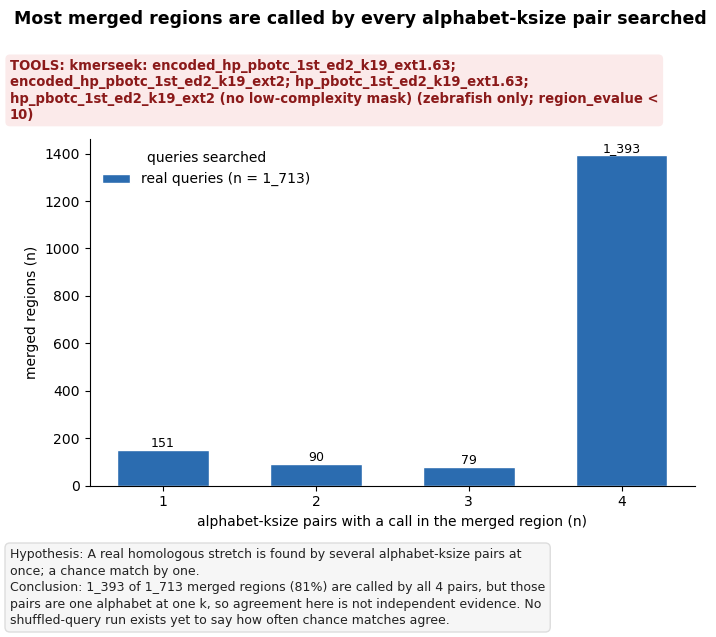

In [5]:
REAL_COLOR, DECOY_COLOR = "#2B6CB0", "#C05621"
real_h = arms_hist.with_columns(set=pl.lit("real queries"))
parts = [real_h]
if decoy_table is not None:
    dreg = decoy_table.unique(subset=KEY)
    parts.append(dreg.group_by("n_arms").len("n_merged_regions").sort("n_arms")
                 .with_columns(set=pl.lit("shuffled queries")))
hist = pl.concat(parts).with_columns(
    fraction=pl.col("n_merged_regions") / pl.col("n_merged_regions").sum().over("set"))
print(hist)

fig, ax = plt.subplots(figsize=(7, 4.2))
xs = sorted(hist["n_arms"].unique().to_list())
width = 0.38 if decoy_table is not None else 0.6
for i, (name, color, hatch) in enumerate((("real queries", REAL_COLOR, None),
                                          ("shuffled queries", DECOY_COLOR, "//"))):
    h = hist.filter(pl.col("set") == name)
    if h.is_empty():
        continue
    off = (i - 0.5) * width if decoy_table is not None else 0
    ax.bar(np.array(h["n_arms"]) + off, h["n_merged_regions"], width=width,
           color=color, hatch=hatch, edgecolor="white", label=f"{name} (n = {h['n_merged_regions'].sum():_})")
    for x, y in zip(h["n_arms"], h["n_merged_regions"]):
        ax.text(x + off, y, f"{y:_}", ha="center", va="bottom", fontsize=9)
ax.set_xticks(xs)
ax.set_xlabel("alphabet-ksize pairs with a call in the merged region (n)")
ax.set_ylabel("merged regions (n)")
ax.legend(loc="upper left", frameon=False, title="queries searched")
ax.spines[["top", "right"]].set_visible(False)
n_pairs = calls["arm"].n_unique()
top = arms_hist.filter(pl.col("n_arms") == arms_hist["n_arms"].max())
mu.finish_figure(
    fig, FIG / "260_arms_per_merged_region.png",
    tools=mu.tools_text(kmerseek=sorted(calls["arm"].unique().to_list()),
                        lc=False, note="zebrafish only; region_evalue < 10"),
    title="Most merged regions are called by every alphabet-ksize pair searched",
    hypothesis="A real homologous stretch is found by several alphabet-ksize pairs at once; "
               "a chance match by one.",
    conclusion=(f"{top['n_merged_regions'][0]:_} of {regions.height:_} merged regions "
                f"({top['n_merged_regions'][0] / regions.height:.0%}) are called by all {n_pairs} "
                "pairs, but those pairs are one alphabet at one k, so agreement here is not "
                "independent evidence. No shuffled-query run exists yet to say how often "
                "chance matches agree."),
)

## Merged region length against the number of alphabet-ksize pairs

shape: (4, 5)
┌────────┬──────┬───────────────┬────────────┬──────────────┐
│ n_arms ┆ n    ┆ median_length ┆ q90_length ┆ median_calls │
│ ---    ┆ ---  ┆ ---           ┆ ---        ┆ ---          │
│ u32    ┆ u32  ┆ f64           ┆ f64        ┆ f64          │
╞════════╪══════╪═══════════════╪════════════╪══════════════╡
│ 1      ┆ 151  ┆ 76.0          ┆ 135.0      ┆ 1.0          │
│ 2      ┆ 90   ┆ 77.0          ┆ 130.0      ┆ 2.0          │
│ 3      ┆ 79   ┆ 91.0          ┆ 143.0      ┆ 3.0          │
│ 4      ┆ 1393 ┆ 194.0         ┆ 463.0      ┆ 8.0          │
└────────┴──────┴───────────────┴────────────┴──────────────┘


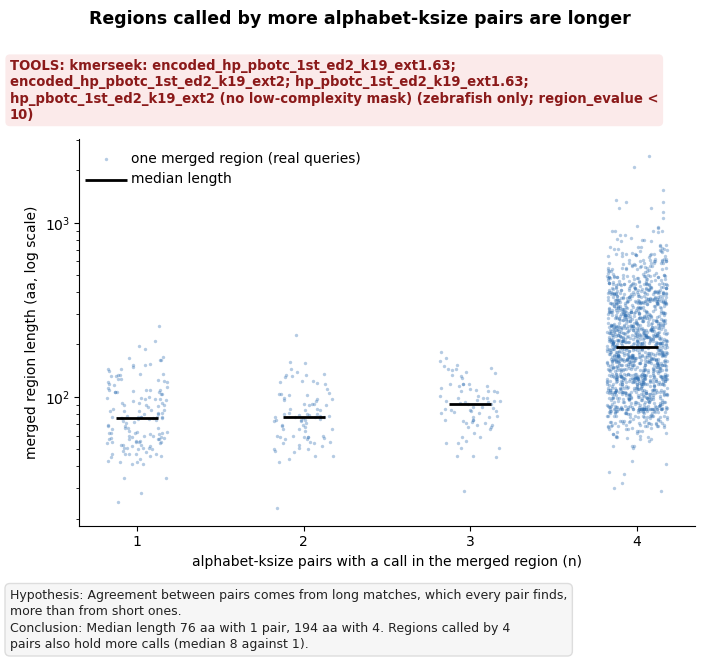

In [6]:
len_tab = (regions.group_by("n_arms")
           .agg(n=pl.len(),
                median_length=pl.col("merged_length").median(),
                q90_length=pl.col("merged_length").quantile(0.9),
                median_calls=pl.col("n_calls_merged").median())
           .sort("n_arms"))
print(len_tab)

rng = np.random.default_rng(260)
fig, ax = plt.subplots(figsize=(7, 4.6))
x = regions["n_arms"].to_numpy() + rng.uniform(-0.18, 0.18, regions.height)
ax.scatter(x, regions["merged_length"], s=6, alpha=0.35, color=REAL_COLOR, linewidths=0,
           label="one merged region (real queries)")
ax.scatter(len_tab["n_arms"], len_tab["median_length"], marker="_", s=900, color="black",
           linewidths=2, label="median length")
ax.set_yscale("log")
ax.set_xticks(len_tab["n_arms"].to_list())
ax.set_xlabel("alphabet-ksize pairs with a call in the merged region (n)")
ax.set_ylabel("merged region length (aa, log scale)")
ax.legend(loc="upper left", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
lo, hi = len_tab.row(0, named=True), len_tab.row(-1, named=True)
mu.finish_figure(
    fig, FIG / "260_merged_length_vs_arms.png",
    tools=mu.tools_text(kmerseek=sorted(calls["arm"].unique().to_list()),
                        lc=False, note="zebrafish only; region_evalue < 10"),
    title="Regions called by more alphabet-ksize pairs are longer",
    hypothesis="Agreement between pairs comes from long matches, which every pair finds, "
               "more than from short ones.",
    conclusion=(f"Median length {lo['median_length']:.0f} aa with {lo['n_arms']} pair, "
                f"{hi['median_length']:.0f} aa with {hi['n_arms']}. Regions called by {hi['n_arms']} pairs "
                f"also hold more calls (median {hi['median_calls']:.0f} against {lo['median_calls']:.0f})."),
)

## One query drawn out: plasminogen (PLG, P00747)

PLG is 810 aa long with seven Pfam domains from three families: a PAN domain, five kringle
domains and a trypsin-like serine protease domain. It was picked by hand from the queries
with at least three Pfam domains from at least two families, at most 1_200 aa, and calls
from every alphabet-ksize pair in zebrafish (the cell below counts them), because its
calls are few enough to draw one by one.

candidate queries: 157; P00747 among them: True
shape: (1, 6)
┌───────────┬───────┬───────┬────────┬─────────┬─────────┐
│ accession ┆ n_dom ┆ n_fam ┆ length ┆ n_calls ┆ n_pairs │
│ ---       ┆ ---   ┆ ---   ┆ ---    ┆ ---     ┆ ---     │
│ str       ┆ u32   ┆ u32   ┆ i32    ┆ u32     ┆ u32     │
╞═══════════╪═══════╪═══════╪════════╪═════════╪═════════╡
│ P00747    ┆ 7     ┆ 3     ┆ 810    ┆ 41      ┆ 4       │
└───────────┴───────┴───────┴────────┴─────────┴─────────┘
P00747: 41 zebrafish calls, 35 land >= 0.5 in one Pfam domain
shape: (41, 8)
┌──────────────────────────────────────┬────────────┬──────────┬───────────────┬──────────────┬─────────┬──────────┬──────────────────────────────────┐
│ arm                                  ┆ call_start ┆ call_end ┆ region_evalue ┆ region_tfidf ┆ feature ┆ landed   ┆ target_name                      │
│ ---                                  ┆ ---        ┆ ---      ┆ ---           ┆ ---          ┆ ---     ┆ ---      ┆ ---                        

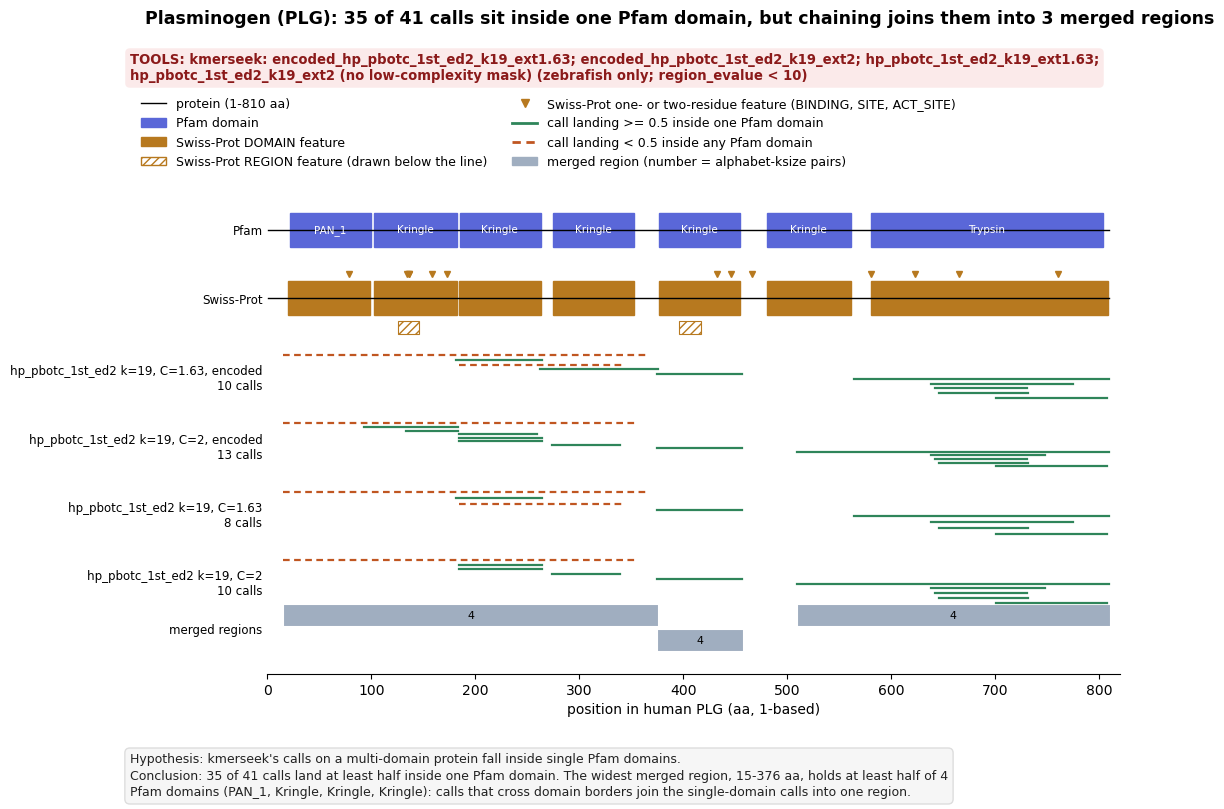

In [7]:
ACC = "P00747"
pf_raw = pl.read_parquet(PFAM_TRUTH)
dom = pf_raw.group_by("accession").agg(n_dom=pl.len(), n_fam=pl.col("pfam_id").n_unique(),
                                      length=pl.col("protein_length").first())
zf = calls.filter(pl.col("species") == "zebrafish").group_by("accession").agg(
    n_calls=pl.len(), n_pairs=pl.col("arm").n_unique())
cand = dom.join(zf, on="accession").filter(
    (pl.col("n_dom") >= 3) & (pl.col("n_fam") >= 2) & (pl.col("length") <= 1_200)
    & (pl.col("n_pairs") == calls.filter(pl.col("species") == "zebrafish")["arm"].n_unique()))
print(f"candidate queries: {cand.height}; {ACC} among them: {ACC in cand['accession'].to_list()}")
print(cand.filter(pl.col("accession") == ACC))
names = dict(pl.read_csv(mu.MIDI_DIR / "pfam_a_names.tsv", separator="\t", has_header=False,
                         new_columns=["pfam_id", "short", "long"]).select("pfam_id", "short").iter_rows())
q_calls = (calls.filter((pl.col("accession") == ACC) & (pl.col("species") == "zebrafish"))
           .with_columns(call_start=pl.col("region_start") + 1, call_end=pl.col("region_end")))
pf = truth.filter((pl.col("accession") == ACC) & (pl.col("truth_set") == "pfam")).sort("feature_start")
sp = truth.filter((pl.col("accession") == ACC) & (pl.col("truth_set") == "swissprot")).sort("feature_start")
pairs = rt.region_truth_pairs(q_calls.select("arm", "call_start", "call_end", "accession",
                                              "target_name", "region_evalue"),
                              pf, "call_start", "call_end")
best = (pairs.sort("landed", descending=True)
        .unique(subset=["arm", "call_start", "call_end", "target_name"], keep="first"))
q_calls = q_calls.join(best.select("arm", "call_start", "call_end", "target_name", "feature", "landed"),
                       on=["arm", "call_start", "call_end", "target_name"], how="left") \
                 .with_columns(is_true=pl.col("landed").fill_null(0) >= rt.LANDED_MIN)
q_reg = regions.filter((pl.col("accession") == ACC) & (pl.col("species") == "zebrafish"))
print(f"{ACC}: {q_calls.height} zebrafish calls, {q_calls['is_true'].sum()} land >= 0.5 in one Pfam domain")
print(q_calls.select("arm", "call_start", "call_end", "region_evalue", "region_tfidf", "feature",
                     "landed", pl.col("target_name").str.slice(0, 32)).sort("arm", "call_start"))
print(q_reg.select("merged_region_id", "merged_start", "merged_end", "n_arms", "n_calls_merged",
                   "merged_pfam_feature", "merged_pfam_landed", "merged_pfam_coverage"))

L = int(pf_raw.filter(pl.col("accession") == ACC)["protein_length"][0])
arms_order = sorted(q_calls["arm"].unique().to_list())
TRUE_C, FALSE_C, PFAM_C, SP_C, MERGED_C = "#2F855A", "#C05621", "#5A67D8", "#B7791F", "#A0AEC0"
fig, ax = plt.subplots(figsize=(11, 6.6))
y = 0.0
rows = []
# legend first, then tracks top to bottom
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
handles = [
    Line2D([], [], color="black", lw=1), Patch(color=PFAM_C), Patch(color=SP_C),
    Patch(facecolor="white", edgecolor=SP_C, hatch="////"),
    Line2D([], [], color=SP_C, marker="v", lw=0),
    Line2D([], [], color=TRUE_C, lw=2), Line2D([], [], color=FALSE_C, lw=2, ls=(0, (3, 2))),
    Patch(color=MERGED_C),
]
labels = [f"protein (1-{L} aa)", "Pfam domain", "Swiss-Prot DOMAIN feature",
          "Swiss-Prot REGION feature (drawn below the line)",
          "Swiss-Prot one- or two-residue feature (BINDING, SITE, ACT_SITE)",
          "call landing >= 0.5 inside one Pfam domain", "call landing < 0.5 inside any Pfam domain",
          "merged region (number = alphabet-ksize pairs)"]
fig.legend(handles, labels, loc="upper left", bbox_to_anchor=(0.0, 1.0), ncol=2, frameon=False, fontsize=9)

def pair_label(arm: str) -> str:
    # encoded_hp_pbotc_1st_ed2_k19_ext1.63 -> "hp_pbotc_1st_ed2 k=19, C=1.63, encoded"
    import re
    m = re.match(r"(encoded_)?(.+)_k(\d+)(?:_ext([0-9.]+))?$", arm)
    enc, alpha, k, c = m.groups()
    return f"{alpha} k={k}" + (f", C={c}" if c else "") + (", encoded" if enc else "")

def protein_line(yy):
    ax.plot([1, L], [yy, yy], color="black", lw=1)

protein_line(y); rows.append((y, "Pfam"))
for r in pf.iter_rows(named=True):
    ax.add_patch(plt.Rectangle((r["feature_start"], y - 0.3), r["feature_end"] - r["feature_start"] + 1, 0.6, color=PFAM_C))
    ax.text((r["feature_start"] + r["feature_end"]) / 2, y, names.get(r["feature"], r["feature"]),
            ha="center", va="center", fontsize=7.5, color="white")
y -= 1.2
protein_line(y); rows.append((y, "Swiss-Prot"))
for r in sp.iter_rows(named=True):
    w = r["feature_end"] - r["feature_start"] + 1
    if r["feature"] == "DOMAIN":
        ax.add_patch(plt.Rectangle((r["feature_start"], y - 0.3), w, 0.6, color=SP_C))
    elif r["feature"] == "REGION":
        ax.add_patch(plt.Rectangle((r["feature_start"], y - 0.62), w, 0.22, facecolor="white",
                                   edgecolor=SP_C, hatch="////", lw=0.8))
    else:
        ax.plot((r["feature_start"] + r["feature_end"]) / 2, y + 0.42, marker="v", color=SP_C, ms=5)
y -= 1.0
for arm in arms_order:
    c = q_calls.filter(pl.col("arm") == arm).sort("call_start", "call_end")
    n = c.height
    ys = y - np.linspace(0, 0.75, n) if n > 1 else [y]
    for (r, yy) in zip(c.iter_rows(named=True), ys):
        ax.plot([r["call_start"], r["call_end"]], [yy, yy], lw=1.6,
                color=TRUE_C if r["is_true"] else FALSE_C,
                ls="-" if r["is_true"] else (0, (3, 2)))
    rows.append((y - 0.375, pair_label(arm) + f"\n{n} calls"))
    y -= 1.2
# Neighbouring merged regions can share a few residues; alternate their height so each
# draws as its own box.
for i, r in enumerate(q_reg.sort("merged_start").iter_rows(named=True)):
    yy = y + (0.22 if i % 2 == 0 else -0.22)
    ax.add_patch(plt.Rectangle((r["merged_start"], yy - 0.2), r["merged_end"] - r["merged_start"] + 1, 0.4,
                               facecolor=MERGED_C, edgecolor="white", lw=1.5))
    ax.text((r["merged_start"] + r["merged_end"]) / 2, yy, str(r["n_arms"]), ha="center", va="center", fontsize=8)
rows.append((y, "merged regions"))
ax.set_yticks([r[0] for r in rows]); ax.set_yticklabels([r[1] for r in rows], fontsize=8.5)
ax.set_xlim(0, L + 10); ax.set_ylim(y - 0.8, 0.9)
ax.set_xlabel("position in human PLG (aa, 1-based)")
ax.spines[["top", "right", "left"]].set_visible(False)
ax.tick_params(axis="y", length=0)
fig.subplots_adjust(top=0.86)
n_true = int(q_calls["is_true"].sum())
# Pfam domains each merged region holds at least half of
held = (rt.region_truth_pairs(q_reg.select("accession", "merged_region_id", "merged_start", "merged_end"),
                              pf, "merged_start", "merged_end")
        .filter(pl.col("coverage") >= 0.5)
        .group_by("merged_region_id", "merged_start", "merged_end")
        .agg(domains=pl.col("feature").replace_strict(names, default=pl.col("feature")).str.join(", "),
             n_domains=pl.len())
        .sort("merged_region_id"))
print("Pfam domains each merged region holds at least half of:")
print(held)
widest = held.sort("n_domains", descending=True).row(0, named=True)
mu.finish_figure(
    fig, FIG / "260_PLG_tracks.png",
    tools=mu.tools_text(kmerseek=arms_order, lc=False, note="zebrafish only; region_evalue < 10"),
    title=(f"Plasminogen (PLG): {n_true} of {q_calls.height} calls sit inside one Pfam domain, "
           f"but chaining joins them into {q_reg.height} merged regions"),
    hypothesis="kmerseek's calls on a multi-domain protein fall inside single Pfam domains.",
    conclusion=(f"{n_true} of {q_calls.height} calls land at least half inside one Pfam domain. "
                f"The widest merged region, {widest['merged_start']}-{widest['merged_end']} aa, holds "
                f"at least half of {widest['n_domains']} Pfam domains ({widest['domains']}): calls that "
                "cross domain borders join the single-domain calls into one region."),
    layout=False,
)